# ABC matching: fitting gene-family rates to a profile

Most of ZOMBI2 runs *forward*: given rates, it produces gene families. `match_profiles`
runs the other way. Given

- a **species tree**, and
- an **empirical copy-number profile** (a families × extant-species matrix),

it searches for the duplication / transfer / loss / origination rates under which the
forward model reproduces that profile, by **Approximate Bayesian Computation** (ABC):

1. draw a rate set from priors,
2. simulate a profile,
3. reduce both the simulated and the empirical matrix to **summary statistics**, and
4. keep the draws whose summaries land closest to the empirical one.

In this notebook we *simulate* the "empirical" data from known rates, so we can check how
well the method recovers them. In a real analysis you would load your own matrix with
`z.ProfileMatrix.from_tsv("profiles.tsv")`.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import zombi2 as z

print("zombi2", z.__version__, "| Rust engine available:", z.rust_available())

## 1. A synthetic "empirical" dataset

We fix a species tree and a set of *true* rates, then simulate one dataset from them. The
profile is what we will try to match; the truth is what we hope to recover.

In [ ]:
TRUTH = dict(duplication=0.30, transfer=0.10, loss=0.50, origination=1.50)

tree = z.simulate_species_tree(z.BirthDeath(1.0, 0.3), n_tips=40, age=5.0, seed=1)
empirical = z.simulate_genomes(tree, initial_families=20, seed=101, output="profiles", **TRUTH)

n_fam, n_sp = empirical.matrix.shape
print(f"{n_fam} gene families across {n_sp} extant species")
print("max copy number:", int(empirical.matrix.max()))

## 2. Match summaries, not the table

A simulation produces a *different* set of families, in a different order, with different
labels — so there is no row-to-row correspondence with the empirical table. Matching is
therefore done on **permutation-invariant** summaries of the whole matrix. The default is
three blocks: the **gene frequency spectrum** (how many families sit in exactly *k*
species — the pangenome core/shell/cloud curve), the **genome sizes**, and the
**copy-number spectrum**.

The frequency spectrum is the single most informative one:

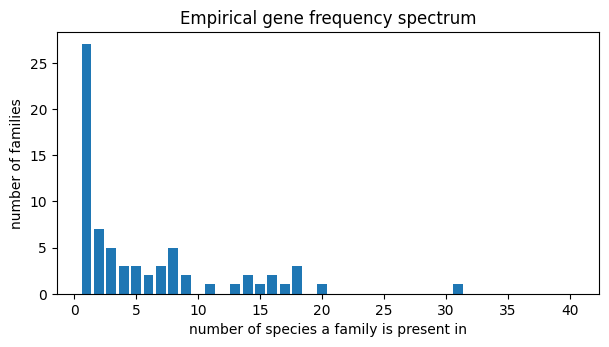

In [3]:
S = empirical.matrix.shape[1]
spectrum = z.frequency_spectrum(empirical, S)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(np.arange(1, S + 1), spectrum, color="C0")
ax.set_xlabel("number of species a family is present in")
ax.set_ylabel("number of families")
ax.set_title("Empirical gene frequency spectrum")
plt.show()

## 3. Run the matcher

Priors are given per rate as `(low, high)` tuples (uniform). We draw many rate sets, keep
the closest 2%, and read the result. Because the rates are only partly identifiable (more
on that below), the result is a **posterior sample, not a point estimate**.

In [4]:
priors = {"duplication": (0, 1.0), "transfer": (0, 0.5),
          "loss": (0, 1.5), "origination": (0, 3.0)}

fit = z.match_profiles(tree, empirical, priors=priors,
                       n_sims=6000, accept=0.02, initial_families=20, seed=1)
fit

ABCFit(n_accept=120, tol=7.44, duplication=0.503 [0.0389, 0.984], transfer=0.214 [0.00488, 0.481], loss=0.863 [0.362, 1.43], origination=1.74 [0.574, 2.91])

In [5]:
print(f"{'rate':<12}{'truth':>7}{'median':>9}   95% credible interval")
for p in z.matching.RATE_PARAMS:
    s = fit.summary()[p]
    print(f"{p:<12}{TRUTH[p]:>7.2f}{s['median']:>9.2f}   [{s['lo95']:.2f}, {s['hi95']:.2f}]")

rate          truth   median   95% credible interval
duplication    0.30     0.50   [0.04, 0.98]
transfer       0.10     0.21   [0.00, 0.48]
loss           0.50     0.86   [0.36, 1.43]
origination    1.50     1.74   [0.57, 2.91]


## 4. Does the fit reproduce the data?

`plot_spectra()` is a posterior-predictive check: it overlays the empirical frequency
spectrum on the spectra of the accepted simulations. If the empirical curve sits inside the
accepted band, the model can reproduce your data.

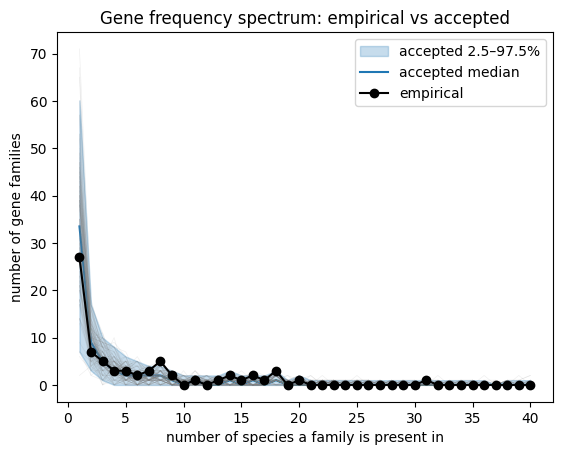

In [6]:
fit.plot_spectra(draws=True)
plt.show()

## 5. What is — and isn't — identifiable

Here is the key caveat. From copy number alone, the **gain-side rates
(duplication, transfer, origination) are well identified**, but **loss is not**: a fully
lost lineage leaves little observable trace, so a whole *ridge* of (origination, loss)
pairs fits the data about equally well. The scatter on the left shows the accepted draws
strung along that ridge; the box plot on the right shows each rate's posterior against the
truth (normalised to its prior range).

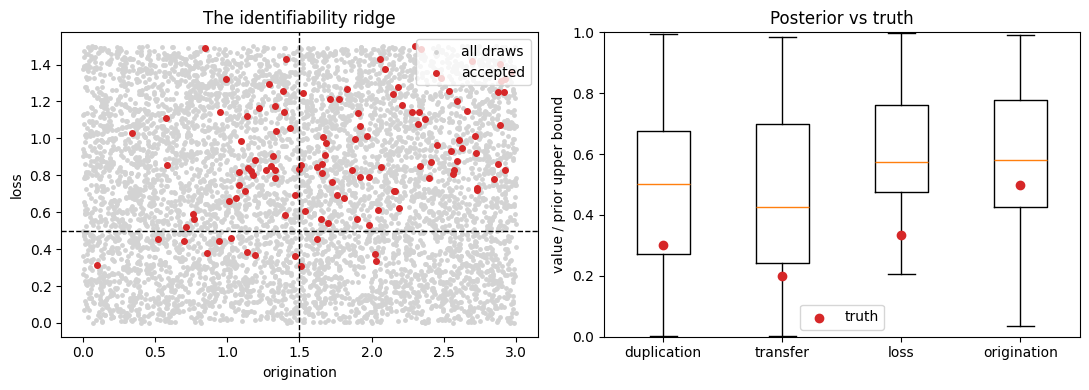

In [7]:
post = fit.posterior
names = list(fit.param_names)
hi = {p: priors[p][1] for p in names}

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter(fit.samples[:, names.index("origination")],
              fit.samples[:, names.index("loss")], s=6, c="lightgray", label="all draws")
ax[0].scatter(post["origination"], post["loss"], s=16, c="C3", label="accepted")
ax[0].axvline(TRUTH["origination"], ls="--", c="k", lw=1)
ax[0].axhline(TRUTH["loss"], ls="--", c="k", lw=1)
ax[0].set_xlabel("origination"); ax[0].set_ylabel("loss")
ax[0].set_title("The identifiability ridge"); ax[0].legend()

ax[1].boxplot([post[p] / hi[p] for p in names], tick_labels=names, showfliers=False)
ax[1].scatter(range(1, len(names) + 1), [TRUTH[p] / hi[p] for p in names],
              c="C3", zorder=3, label="truth")
ax[1].set_ylim(0, 1); ax[1].set_ylabel("value / prior upper bound")
ax[1].set_title("Posterior vs truth"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Sharper estimates

Three tools push against these limits. Their honest scope: they sharpen the *identifiable*
rates; none fully resolves the loss ridge.

### 6a. Regression adjustment

A post-hoc correction (Beaumont 2002) that regresses the accepted parameters on their
summary residuals and shifts them toward the empirical target — **no extra simulations**.

In [8]:
raw, adj = fit.summary(), fit.summary(adjusted=True)
print(f"{'rate':<12}{'raw median':>12}{'adjusted':>11}{'truth':>8}")
for p in z.matching.RATE_PARAMS:
    print(f"{p:<12}{raw[p]['median']:>12.2f}{adj[p]['median']:>11.2f}{TRUTH[p]:>8.2f}")

rate          raw median   adjusted   truth
duplication         0.50       0.38    0.30
transfer            0.21       0.09    0.10
loss                0.86       0.48    0.50
origination         1.74       1.44    1.50


### 6b. Gene-tree information

If you have gene trees, pass an empirical `Genomes` and set `gene_trees=True`. The summary
then also uses duplication/transfer/loss **event counts**, which pin the gain-side rates
sharply. Simulations then return the full genealogy (`output="genomes"`), so we use a
smaller tree to keep it quick.

In [9]:
tree_g = z.simulate_species_tree(z.BirthDeath(1.0, 0.3), n_tips=15, age=5.0, seed=2)
emp_g = z.simulate_genomes(tree_g, **TRUTH, initial_families=15, seed=101)   # a Genomes

fit_prof = z.match_profiles(tree_g, emp_g.profiles, priors=priors,
                            n_sims=800, accept=0.05, initial_families=15, seed=3)
fit_gt = z.match_profiles(tree_g, emp_g, priors=priors, gene_trees=True,
                          n_sims=800, accept=0.05, initial_families=15, seed=3)

print(f"{'rate':<12}{'profile':>10}{'+gene trees':>14}{'truth':>8}")
for p in z.matching.RATE_PARAMS:
    print(f"{p:<12}{fit_prof.summary()[p]['median']:>10.2f}"
          f"{fit_gt.summary()[p]['median']:>14.2f}{TRUTH[p]:>8.2f}")

rate           profile   +gene trees   truth
duplication       0.54          0.43    0.30
transfer          0.25          0.21    0.10
loss              0.62          0.75    0.50
origination       1.84          2.02    1.50


### 6c. Sequential Monte Carlo

`match_profiles_smc` evolves a population of particles over rounds with a shrinking
tolerance, reaching a given tolerance with fewer simulations than plain rejection. It
returns a **weighted** posterior. (For copy-number profiles it typically matches rejection,
since the posterior width is set by the data, not the tolerance — but it pays off for
sharply identified models.)

In [10]:
smc = z.match_profiles_smc(tree, empirical, priors=priors,
                           rounds=5, n_particles=200, initial_families=20, seed=1)
print(f"SMC used {smc.n_simulations} simulations; final tolerance {smc.tolerance:.2f}\n")
for p in z.matching.RATE_PARAMS:
    s = smc.summary()[p]
    print(f"{p:<12} {s['median']:.2f}  [{s['lo95']:.2f}, {s['hi95']:.2f}]   truth {TRUTH[p]:.2f}")

SMC used 15236 simulations; final tolerance 7.62

duplication  0.48  [0.03, 0.97]   truth 0.30
transfer     0.26  [0.02, 0.48]   truth 0.10
loss         0.97  [0.40, 1.47]   truth 0.50
origination  1.70  [0.31, 2.97]   truth 1.50


## 7. Fitting a richer model

By default `match_profiles` fits four scalar rates shared by every family. `model="family"`
instead fits them as the *means* of per-family rate distributions
(`FamilySampledRates`), so families are heterogeneous. This runs on the Python engine, so
cap growth with `max_family_size`.

In [11]:
tree_f = z.simulate_species_tree(z.BirthDeath(1.0, 0.3), n_tips=15, age=5.0, seed=4)
emp_f = z.simulate_genomes(
    tree_f, z.FamilySampledRates(duplication=z.Gamma(2, 0.15), transfer=z.Gamma(2, 0.05),
                                 loss=z.Gamma(2, 0.30), origination=1.5),
    initial_families=15, max_family_size=25, seed=101).profiles

fit_f = z.match_profiles(tree_f, emp_f, priors=priors, model="family", family_shape=2.0,
                         max_family_size=25, n_sims=400, accept=0.1, initial_families=15, seed=5)
print("recovered per-family rate MEANS (truth: dup 0.30, tran 0.10, loss 0.60, orig 1.50):")
for p in z.matching.RATE_PARAMS:
    s = fit_f.summary()[p]
    print(f"  {p:<12} {s['median']:.2f}  [{s['lo95']:.2f}, {s['hi95']:.2f}]")

recovered per-family rate MEANS (truth: dup 0.30, tran 0.10, loss 0.60, orig 1.50):
  duplication  0.32  [0.01, 0.83]
  transfer     0.17  [0.01, 0.48]
  loss         1.08  [0.38, 1.49]
  origination  1.93  [0.78, 2.99]


## Takeaways

- **Match summaries, not the table.** The default frequency spectrum + genome sizes +
  copy-number spectrum are permutation-invariant, so they compare simulations to the
  empirical matrix without needing matching family labels.
- **You get a posterior, not a point.** Read `summary()` credible intervals and check the
  fit with `plot_spectra()`; `best` is just one point on a ridge.
- **Gain-side rates (D/T/O) are well identified; loss is not.** That is an information
  limit of copy-number data, not a bug — regression adjustment, gene-tree counts, and SMC
  sharpen the identifiable rates but do not fully resolve loss.
- **Speed:** the default uniform model runs on the Rust engine; pass `processes=N` (from a
  `__main__` guard) for the embarrassingly parallel inner loop. `model="family"` and
  callable models use the Python engine — cap growth with `max_family_size`.

See the guide page *Matching empirical profiles* and the
`examples/profile_matching_experiment.py` / `profile_matching_scaling.py` scripts for more.